In [42]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import wfdb
import neurokit2 as nk

from scipy.signal import butter, filtfilt, iirnotch

warnings.filterwarnings("ignore")

In [43]:
PROJECT_DIR = Path.cwd()

DATASET_DIR = PROJECT_DIR / "ptb-diagnostic-ecg-database-1.0.0"

DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"

RESULTS_DIR = PROJECT_DIR / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

detection_path = PROCESSED_DIR / "ptb_detection_records.csv"
preprocessing_config_path = TABLE_DIR / "notebook2_preprocessing_config.json"

print("Project directory:", PROJECT_DIR)
print("Dataset exists:", DATASET_DIR.exists())
print("Detection file exists:", detection_path.exists())
print("Preprocessing config exists:", preprocessing_config_path.exists())

if not detection_path.exists():
    raise FileNotFoundError("ptb_detection_records.csv not found. Please run Notebook 1 first.")

Project directory: d:\HUST\ET4248E - Học máy trong y tế\Final Project
Dataset exists: True
Detection file exists: True
Preprocessing config exists: True


In [44]:
PURPLE_MAIN = "#C599B6"
PURPLE_DARK = "#8A5A78"
PURPLE_MID = "#B77FA0"
PURPLE_LIGHT = "#E8D3DF"
PURPLE_VERY_LIGHT = "#F5EAF1"
GRAY = "#6B6B6B"
RED_SOFT = "#C44E52"

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [45]:
detection_df = pd.read_csv(detection_path)

print("Detection dataset shape:", detection_df.shape)

print("\nRecord-level class distribution:")
display(detection_df["mi_detected"].value_counts())

display(detection_df.head())

Detection dataset shape: (448, 15)

Record-level class distribution:


mi_detected
1    368
0     80
Name: count, dtype: int64

,patient_id,record_id,record_path,age,sex,reason_for_admission,raw_localization,fs,n_sig,sig_len,duration_sec,comments_text,mi_detected,healthy_control,broad_group
0,patient001,s0010_re,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,81.0,female,Myocardial infarction,inferior,1000,15,38400,38.4,age: 81 | sex: female | ECG date: 01/10/1990 |...,1,0,Myocardial Infarction
1,patient001,s0014lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,81.0,female,Myocardial infarction,inferior,1000,15,115200,115.2,age: 81 | sex: female | ECG date: 17/10/1990 |...,1,0,Myocardial Infarction
2,patient001,s0016lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,81.0,female,Myocardial infarction,inferior,1000,15,115200,115.2,age: 81 | sex: female | ECG date: 18/10/1990 |...,1,0,Myocardial Infarction
3,patient002,s0015lre,ptb-diagnostic-ecg-database-1.0.0\patient002\s...,58.0,female,Myocardial infarction,anterior,1000,15,115200,115.2,age: 58 | sex: female | ECG date: 17/10/1990 |...,1,0,Myocardial Infarction
4,patient003,s0017lre,ptb-diagnostic-ecg-database-1.0.0\patient003\s...,63.0,male,Myocardial infarction,infero-lateral+infero-postero-lateral+posterio...,1000,15,115200,115.2,age: 63 | sex: male | ECG date: 18/10/1990 | D...,1,0,Myocardial Infarction


In [46]:
if preprocessing_config_path.exists():
    with open(preprocessing_config_path, "r", encoding="utf-8") as f:
        PREPROCESSING_CONFIG = json.load(f)
else:
    PREPROCESSING_CONFIG = {
        "bandpass_low_hz": 0.5,
        "bandpass_high_hz": 40.0,
        "notch_hz": 50.0,
        "notch_quality_factor": 30.0,
        "apply_notch": True,
        "normalization": "per_lead_z_score"
    }

print(json.dumps(PREPROCESSING_CONFIG, indent=4))

{
    "bandpass_low_hz": 0.5,
    "bandpass_high_hz": 40.0,
    "notch_hz": 50.0,
    "notch_quality_factor": 30.0,
    "apply_notch": true,
    "normalization": "per_lead_z_score"
}


In [47]:
STANDARD_12_LEADS = [
    "i", "ii", "iii",
    "avr", "avl", "avf",
    "v1", "v2", "v3", "v4", "v5", "v6"
]

LEAD_DISPLAY_NAMES = {
    "i": "I",
    "ii": "II",
    "iii": "III",
    "avr": "aVR",
    "avl": "aVL",
    "avf": "aVF",
    "v1": "V1",
    "v2": "V2",
    "v3": "V3",
    "v4": "V4",
    "v5": "V5",
    "v6": "V6"
}

print(STANDARD_12_LEADS)

['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6']


In [48]:
def load_ecg_record(record_path_relative):
    """
    Load one ECG record using WFDB.
    """
    record_path = PROJECT_DIR / record_path_relative

    signal, fields = wfdb.rdsamp(str(record_path))

    lead_names = [str(ch).lower() for ch in fields["sig_name"]]
    fs = fields["fs"]

    record_info = {
        "fs": fs,
        "lead_names": lead_names,
        "units": fields.get("units", None),
        "n_samples": signal.shape[0],
        "n_channels": signal.shape[1],
        "duration_sec": signal.shape[0] / fs
    }

    return signal, fs, lead_names, record_info

In [49]:
def select_standard_12_leads(signal, lead_names):
    """
    Select and reorder ECG signal to standard 12-lead order:
    I, II, III, aVR, aVL, aVF, V1-V6.
    """
    lead_to_idx = {lead.lower(): idx for idx, lead in enumerate(lead_names)}

    missing_leads = [
        lead for lead in STANDARD_12_LEADS
        if lead not in lead_to_idx
    ]

    if len(missing_leads) > 0:
        raise ValueError(f"Missing leads: {missing_leads}")

    selected_indices = [lead_to_idx[lead] for lead in STANDARD_12_LEADS]
    selected_signal = signal[:, selected_indices]

    return selected_signal, STANDARD_12_LEADS

In [50]:
def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    """
    Zero-phase Butterworth bandpass filter.
    """
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype="bandpass")
    filtered = filtfilt(b, a, signal, axis=0)

    return filtered


def notch_filter(signal, fs, notch_freq=50.0, quality_factor=30.0):
    """
    Zero-phase notch filter for powerline interference.
    """
    b, a = iirnotch(
        w0=notch_freq,
        Q=quality_factor,
        fs=fs
    )

    filtered = filtfilt(b, a, signal, axis=0)

    return filtered


def zscore_normalize_per_lead(signal, eps=1e-8):
    """
    Per-lead z-score normalization.
    """
    mean = np.mean(signal, axis=0)
    std = np.std(signal, axis=0)

    normalized = (signal - mean) / (std + eps)

    return normalized, mean, std


def preprocess_ecg_signal(signal, fs, config=PREPROCESSING_CONFIG):
    """
    Apply ECG preprocessing:
    1. Bandpass filtering
    2. Optional notch filtering
    3. Per-lead z-score normalization
    """
    filtered = bandpass_filter(
        signal,
        fs,
        lowcut=config["bandpass_low_hz"],
        highcut=config["bandpass_high_hz"],
        order=4
    )

    if config["apply_notch"]:
        filtered = notch_filter(
            filtered,
            fs,
            notch_freq=config["notch_hz"],
            quality_factor=config["notch_quality_factor"]
        )

    normalized, mean_per_lead, std_per_lead = zscore_normalize_per_lead(filtered)

    preprocessing_info = {
        "filtered_mean_per_lead": mean_per_lead,
        "filtered_std_per_lead": std_per_lead,
        "normalized_mean_per_lead": np.mean(normalized, axis=0),
        "normalized_std_per_lead": np.std(normalized, axis=0)
    }

    return filtered, normalized, preprocessing_info

In [51]:
# NeuroKit2 R-peak detection helper
def detect_r_peaks_neurokit_best_direction(
    ecg_lead,
    fs,
    method="neurokit",
    correct_artifacts=True,
    min_hr=35,
    max_hr=180
):
    """
    Detect R-peaks using NeuroKit2.

    The function tries both:
    1. original ECG lead
    2. inverted ECG lead

    This helps handle records where QRS morphology is inverted.
    The best direction is selected based on physiological HR plausibility,
    number of detected peaks, and RR interval stability.
    """
    candidates = []

    for direction_name, signal_used in [
        ("original", ecg_lead),
        ("inverted", -ecg_lead)
    ]:
        try:
            cleaned = nk.ecg_clean(
                signal_used,
                sampling_rate=fs,
                method=method
            )

            _, info = nk.ecg_peaks(
                cleaned,
                sampling_rate=fs,
                method=method,
                correct_artifacts=correct_artifacts
            )

            r_peaks = np.array(info["ECG_R_Peaks"], dtype=int)

            duration_sec = len(ecg_lead) / fs
            hr_count = len(r_peaks) / duration_sec * 60 if duration_sec > 0 else np.nan

            if len(r_peaks) >= 3:
                rr_sec = np.diff(r_peaks) / fs
                rr_median = np.median(rr_sec)
                rr_std = np.std(rr_sec)
                hr_median = 60 / rr_median if rr_median > 0 else np.nan
            else:
                rr_std = np.inf
                hr_median = np.nan

            plausible_hr = (
                np.isfinite(hr_count)
                and hr_count >= min_hr
                and hr_count <= max_hr
            )

            candidates.append({
                "direction": direction_name,
                "cleaned": cleaned,
                "r_peaks": r_peaks,
                "n_peaks": len(r_peaks),
                "hr_count": hr_count,
                "hr_median": hr_median,
                "rr_std": rr_std,
                "plausible_hr": plausible_hr
            })

        except Exception as e:
            candidates.append({
                "direction": direction_name,
                "cleaned": signal_used,
                "r_peaks": np.array([], dtype=int),
                "n_peaks": 0,
                "hr_count": np.nan,
                "hr_median": np.nan,
                "rr_std": np.inf,
                "plausible_hr": False,
                "error": str(e)
            })

    candidates_sorted = sorted(
        candidates,
        key=lambda x: (
            x["plausible_hr"],
            x["n_peaks"],
            -x["rr_std"] if np.isfinite(x["rr_std"]) else -1e9
        ),
        reverse=True
    )

    best = candidates_sorted[0]

    return best, candidates

In [52]:
def detect_r_peaks_neurokit_best_direction(
    ecg_lead,
    fs,
    method="neurokit",
    correct_artifacts=True,
    min_hr=35,
    max_hr=180
):
    """
    Detect R-peaks using NeuroKit2.

    The function tries both:
    1. original ECG lead
    2. inverted ECG lead

    This helps handle records where QRS morphology is inverted.
    The best direction is selected based on physiological HR plausibility,
    number of detected peaks, and RR interval stability.
    """
    candidates = []

    for direction_name, signal_used in [
        ("original", ecg_lead),
        ("inverted", -ecg_lead)
    ]:
        try:
            cleaned = nk.ecg_clean(
                signal_used,
                sampling_rate=fs,
                method=method
            )

            _, info = nk.ecg_peaks(
                cleaned,
                sampling_rate=fs,
                method=method,
                correct_artifacts=correct_artifacts
            )

            r_peaks = np.array(info["ECG_R_Peaks"], dtype=int)

            duration_sec = len(ecg_lead) / fs
            hr_count = len(r_peaks) / duration_sec * 60 if duration_sec > 0 else np.nan

            if len(r_peaks) >= 3:
                rr_sec = np.diff(r_peaks) / fs
                rr_median = np.median(rr_sec)
                rr_std = np.std(rr_sec)
                hr_median = 60 / rr_median if rr_median > 0 else np.nan
            else:
                rr_std = np.inf
                hr_median = np.nan

            plausible_hr = (
                np.isfinite(hr_count)
                and hr_count >= min_hr
                and hr_count <= max_hr
            )

            candidates.append({
                "direction": direction_name,
                "cleaned": cleaned,
                "r_peaks": r_peaks,
                "n_peaks": len(r_peaks),
                "hr_count": hr_count,
                "hr_median": hr_median,
                "rr_std": rr_std,
                "plausible_hr": plausible_hr
            })

        except Exception as e:
            candidates.append({
                "direction": direction_name,
                "cleaned": signal_used,
                "r_peaks": np.array([], dtype=int),
                "n_peaks": 0,
                "hr_count": np.nan,
                "hr_median": np.nan,
                "rr_std": np.inf,
                "plausible_hr": False,
                "error": str(e)
            })

    candidates_sorted = sorted(
        candidates,
        key=lambda x: (
            x["plausible_hr"],
            x["n_peaks"],
            -x["rr_std"] if np.isfinite(x["rr_std"]) else -1e9
        ),
        reverse=True
    )

    best = candidates_sorted[0]

    return best, candidates

In [54]:
# Test
mi_example_row = detection_df[detection_df["mi_detected"] == 1].iloc[0]

print("MI example:")
display(mi_example_row[["patient_id", "record_id", "record_path", "reason_for_admission"]])

raw_signal, fs, lead_names, record_info = load_ecg_record(mi_example_row["record_path"])
raw_12lead, selected_leads = select_standard_12_leads(raw_signal, lead_names)

filtered_12lead, normalized_12lead, preprocessing_info = preprocess_ecg_signal(
    raw_12lead,
    fs,
    PREPROCESSING_CONFIG
)

print("Raw 12-lead shape:", raw_12lead.shape)
print("Filtered 12-lead shape:", filtered_12lead.shape)
print("Normalized 12-lead shape:", normalized_12lead.shape)
print("Sampling frequency:", fs)
print("Duration:", record_info["duration_sec"])

MI example:


patient_id                                                     patient001
record_id                                                        s0010_re
record_path             ptb-diagnostic-ecg-database-1.0.0\patient001\s...
reason_for_admission                                Myocardial infarction
Name: 0, dtype: object

Raw 12-lead shape: (38400, 12)
Filtered 12-lead shape: (38400, 12)
Normalized 12-lead shape: (38400, 12)
Sampling frequency: 1000
Duration: 38.4


In [55]:
rpeak_lead = "ii"
rpeak_lead_idx = selected_leads.index(rpeak_lead)

# Use filtered Lead II for R-peak detection
lead_signal_for_detection = filtered_12lead[:, rpeak_lead_idx]

# Use normalized Lead II for visualization and segmentation alignment
lead_signal_normalized = normalized_12lead[:, rpeak_lead_idx]

best_detection, all_detection_candidates = detect_r_peaks_neurokit_best_direction(
    lead_signal_for_detection,
    fs,
    method="neurokit",
    correct_artifacts=True
)

r_peaks = best_detection["r_peaks"]
cleaned_detection_signal = best_detection["cleaned"]

rpeak_summary = summarize_r_peaks(
    r_peaks,
    fs,
    signal_length=len(lead_signal_for_detection)
)

print("Detection candidates:")
for candidate in all_detection_candidates:
    print(candidate["direction"])
    print("  n_peaks:", candidate["n_peaks"])
    print("  HR from count:", candidate["hr_count"])
    print("  HR from median RR:", candidate["hr_median"])
    print("  RR std:", candidate["rr_std"])
    print("  plausible HR:", candidate["plausible_hr"])

print("\nSelected direction:", best_detection["direction"])

print("\nR-peak detection summary:")
for k, v in rpeak_summary.items():
    print(f"{k}: {v}")

print("\nFirst 10 R-peaks:")
print(r_peaks[:10])

Detection candidates:
original
  n_peaks: 52
  HR from count: 81.25
  HR from median RR: 81.74386920980926
  RR std: 0.009226110083151846
  plausible HR: True
inverted
  n_peaks: 52
  HR from count: 81.25
  HR from median RR: 81.85538881309687
  RR std: 0.009370046429363501
  plausible HR: True

Selected direction: original

R-peak detection summary:
n_detected_rpeaks: 52
duration_sec: 38.4
estimated_hr_from_count: 81.25
estimated_hr_from_median_rr: 81.74386920980926
rr_mean_sec: 0.733764705882353
rr_median_sec: 0.734
rr_std_sec: 0.009226110083151846

First 10 R-peaks:
[ 639 1383 2111 2839 3584 4325 5054 5797 6539 7262]


In [56]:
def plot_r_peaks_on_signal(
    ecg_lead,
    r_peaks,
    fs,
    title,
    output_path=None,
    start_sec=0,
    duration_sec=10,
    y_label="Amplitude"
):
    """
    Plot ECG signal with detected R-peaks.
    """
    start_sample = int(start_sec * fs)
    end_sample = int((start_sec + duration_sec) * fs)

    segment = ecg_lead[start_sample:end_sample]
    t = np.arange(segment.shape[0]) / fs + start_sec

    peaks_in_window = r_peaks[
        (r_peaks >= start_sample) & (r_peaks < end_sample)
    ]

    plt.figure(figsize=(14, 4))
    plt.plot(t, segment, color=PURPLE_DARK, linewidth=1.0, label="ECG signal")

    plt.scatter(
        peaks_in_window / fs,
        ecg_lead[peaks_in_window],
        color=RED_SOFT,
        s=35,
        label="Detected R-peaks",
        zorder=3
    )

    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel(y_label)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300)

    plt.show()

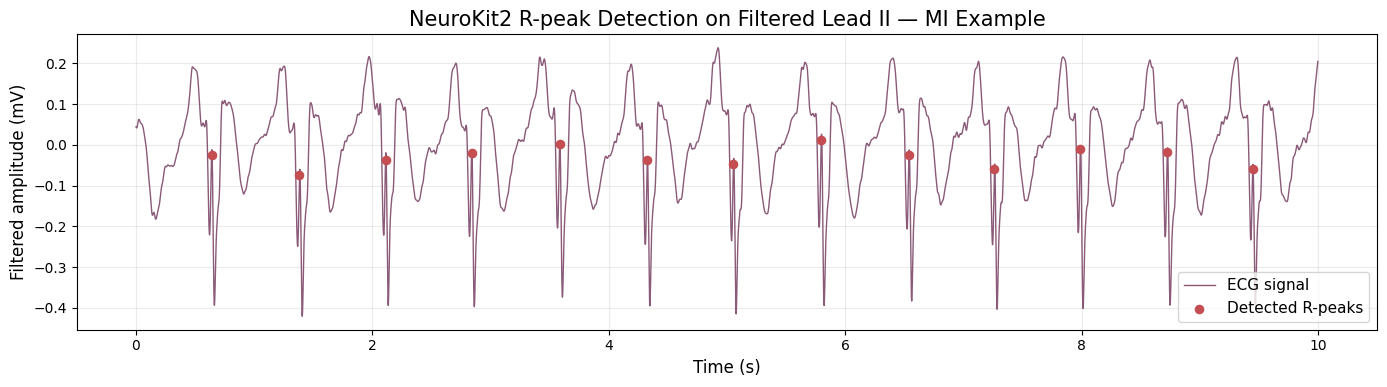

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook3_neurokit_detected_rpeaks_filtered_lead_ii_mi_example.png


In [57]:
fig_path = FIGURE_DIR / "notebook3_neurokit_detected_rpeaks_filtered_lead_ii_mi_example.png"

plot_r_peaks_on_signal(
    lead_signal_for_detection,
    r_peaks,
    fs,
    title="NeuroKit2 R-peak Detection on Filtered Lead II — MI Example",
    output_path=fig_path,
    start_sec=0,
    duration_sec=10,
    y_label="Filtered amplitude (mV)"
)

print("Saved figure to:", fig_path)

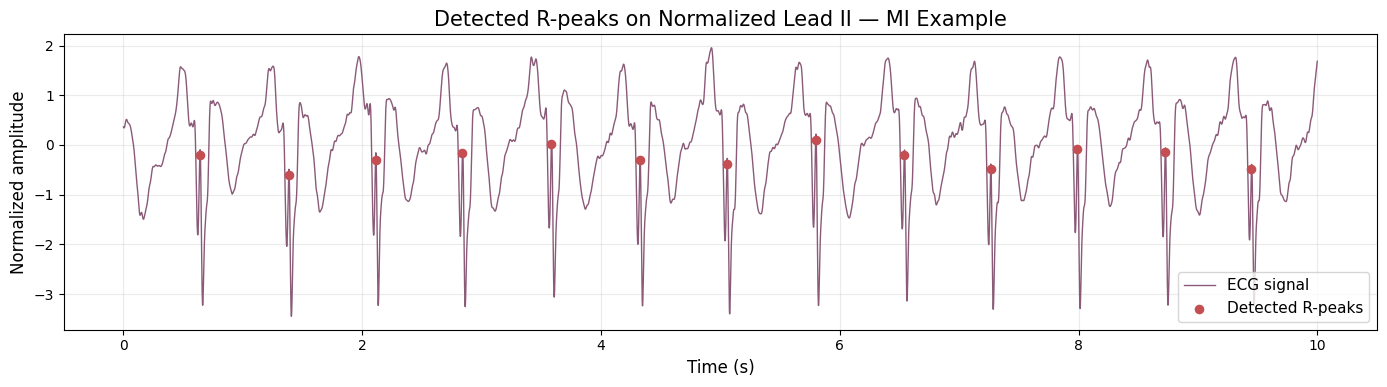

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook3_neurokit_detected_rpeaks_normalized_lead_ii_mi_example.png


In [58]:
fig_path = FIGURE_DIR / "notebook3_neurokit_detected_rpeaks_normalized_lead_ii_mi_example.png"

plot_r_peaks_on_signal(
    lead_signal_normalized,
    r_peaks,
    fs,
    title="Detected R-peaks on Normalized Lead II — MI Example",
    output_path=fig_path,
    start_sec=0,
    duration_sec=10,
    y_label="Normalized amplitude"
)

print("Saved figure to:", fig_path)

In [59]:
# Segmentation configuration
SEGMENTATION_CONFIG = {
    "rpeak_detection_library": "NeuroKit2",
    "rpeak_detection_method": "neurokit",
    "correct_artifacts": True,
    "rpeak_lead": "ii",
    "pre_r_sec": 0.2,
    "post_r_sec": 0.4,
    "beat_window_sec": 0.6,
    "description": "Each beat is segmented from 0.2 s before to 0.4 s after the detected R-peak."
}

print(json.dumps(SEGMENTATION_CONFIG, indent=4))

{
    "rpeak_detection_library": "NeuroKit2",
    "rpeak_detection_method": "neurokit",
    "correct_artifacts": true,
    "rpeak_lead": "ii",
    "pre_r_sec": 0.2,
    "post_r_sec": 0.4,
    "beat_window_sec": 0.6,
    "description": "Each beat is segmented from 0.2 s before to 0.4 s after the detected R-peak."
}


In [60]:
def segment_beats_around_rpeaks(
    signal_12lead,
    r_peaks,
    fs,
    pre_r_sec=0.2,
    post_r_sec=0.4
):
    """
    Segment 12-lead ECG beats around detected R-peaks.

    Output shape:
    n_valid_beats × n_samples_per_beat × n_leads
    """
    pre_samples = int(pre_r_sec * fs)
    post_samples = int(post_r_sec * fs)

    beats = []
    valid_r_peaks = []

    for r in r_peaks:
        start = r - pre_samples
        end = r + post_samples

        if start < 0 or end > signal_12lead.shape[0]:
            continue

        beat = signal_12lead[start:end, :]
        beats.append(beat)
        valid_r_peaks.append(r)

    if len(beats) == 0:
        beats = np.empty((0, pre_samples + post_samples, signal_12lead.shape[1]))
    else:
        beats = np.stack(beats, axis=0)

    valid_r_peaks = np.array(valid_r_peaks, dtype=int)
    beat_time = np.arange(-pre_samples, post_samples) / fs

    return beats, valid_r_peaks, beat_time

In [61]:
beats, valid_r_peaks, beat_time = segment_beats_around_rpeaks(
    normalized_12lead,
    r_peaks,
    fs,
    pre_r_sec=SEGMENTATION_CONFIG["pre_r_sec"],
    post_r_sec=SEGMENTATION_CONFIG["post_r_sec"]
)

print("Segmented beats shape:", beats.shape)
print("Number of detected R-peaks:", len(r_peaks))
print("Number of valid segmented beats:", len(valid_r_peaks))
print("Beat time range:", beat_time[0], "to", beat_time[-1], "seconds")

Segmented beats shape: (51, 600, 12)
Number of detected R-peaks: 52
Number of valid segmented beats: 51
Beat time range: -0.2 to 0.399 seconds


In [62]:
def plot_segmented_beats_one_lead(
    beats,
    beat_time,
    lead_names,
    lead_name="ii",
    title="Segmented beats",
    output_path=None,
    max_beats=50
):
    """
    Plot segmented beats for one lead.
    Individual beats are shown in light purple.
    The average beat is shown in dark purple.
    """
    lead_idx = lead_names.index(lead_name.lower())

    n_plot = min(max_beats, beats.shape[0])

    plt.figure(figsize=(12, 5))

    for i in range(n_plot):
        plt.plot(
            beat_time,
            beats[i, :, lead_idx],
            color=PURPLE_LIGHT,
            linewidth=0.8,
            alpha=0.7
        )

    mean_beat = np.mean(beats[:, :, lead_idx], axis=0)

    plt.plot(
        beat_time,
        mean_beat,
        color=PURPLE_DARK,
        linewidth=2.5,
        label="Average beat"
    )

    plt.axvline(0, color=RED_SOFT, linestyle="--", linewidth=1.5, label="R-peak")

    plt.title(title)
    plt.xlabel("Time relative to R-peak (s)")
    plt.ylabel("Normalized amplitude")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300)

    plt.show()

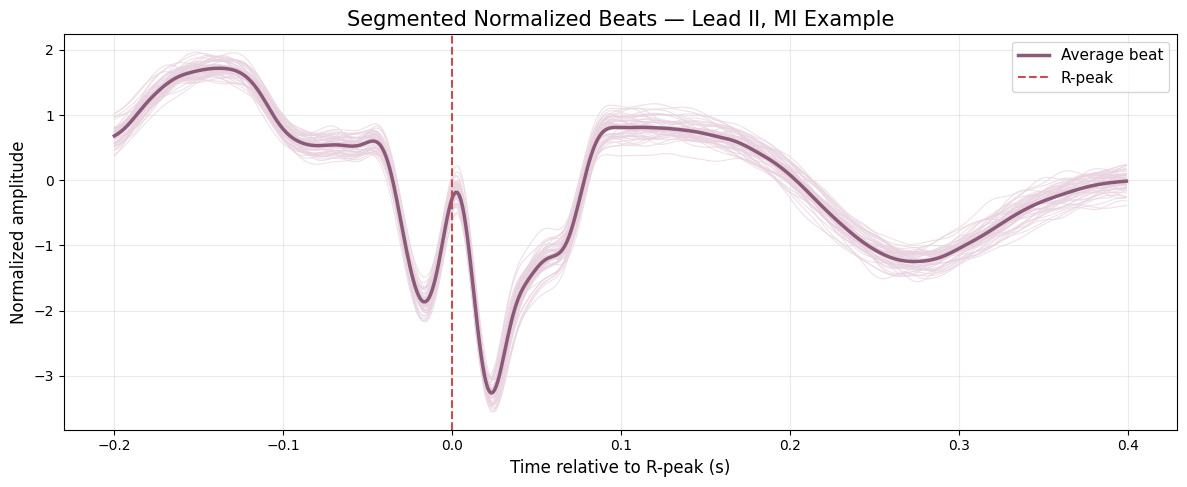

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook3_segmented_beats_lead_ii_mi_example.png


In [63]:
fig_path = FIGURE_DIR / "notebook3_segmented_beats_lead_ii_mi_example.png"

plot_segmented_beats_one_lead(
    beats,
    beat_time,
    selected_leads,
    lead_name="ii",
    title="Segmented Normalized Beats — Lead II, MI Example",
    output_path=fig_path,
    max_beats=50
)

print("Saved figure to:", fig_path)

In [64]:
def plot_average_12lead_beat(
    beats,
    beat_time,
    lead_names,
    title,
    output_path=None
):
    """
    Plot average beat across 12 leads with large vertical spacing.
    """
    avg_beat = np.mean(beats, axis=0)

    n_leads = avg_beat.shape[1]

    # Use automatic spacing to avoid overlap
    max_range = np.max(np.ptp(avg_beat, axis=0))
    spacing = max(max_range * 2.5, 5.0)

    plt.figure(figsize=(13, 12))

    for i in range(n_leads):
        offset = (n_leads - 1 - i) * spacing
        lead_label = LEAD_DISPLAY_NAMES.get(lead_names[i], lead_names[i])

        plt.plot(
            beat_time,
            avg_beat[:, i] + offset,
            color=PURPLE_DARK,
            linewidth=1.2
        )

        plt.text(
            beat_time[0] - 0.025,
            offset,
            lead_label,
            va="center",
            ha="right",
            fontsize=10,
            color="black"
        )

    plt.axvline(0, color=RED_SOFT, linestyle="--", linewidth=1.4)

    plt.title(title)
    plt.xlabel("Time relative to R-peak (s)")
    plt.ylabel("Average normalized amplitude with vertical offset")
    plt.grid(alpha=0.25)
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300)

    plt.show()

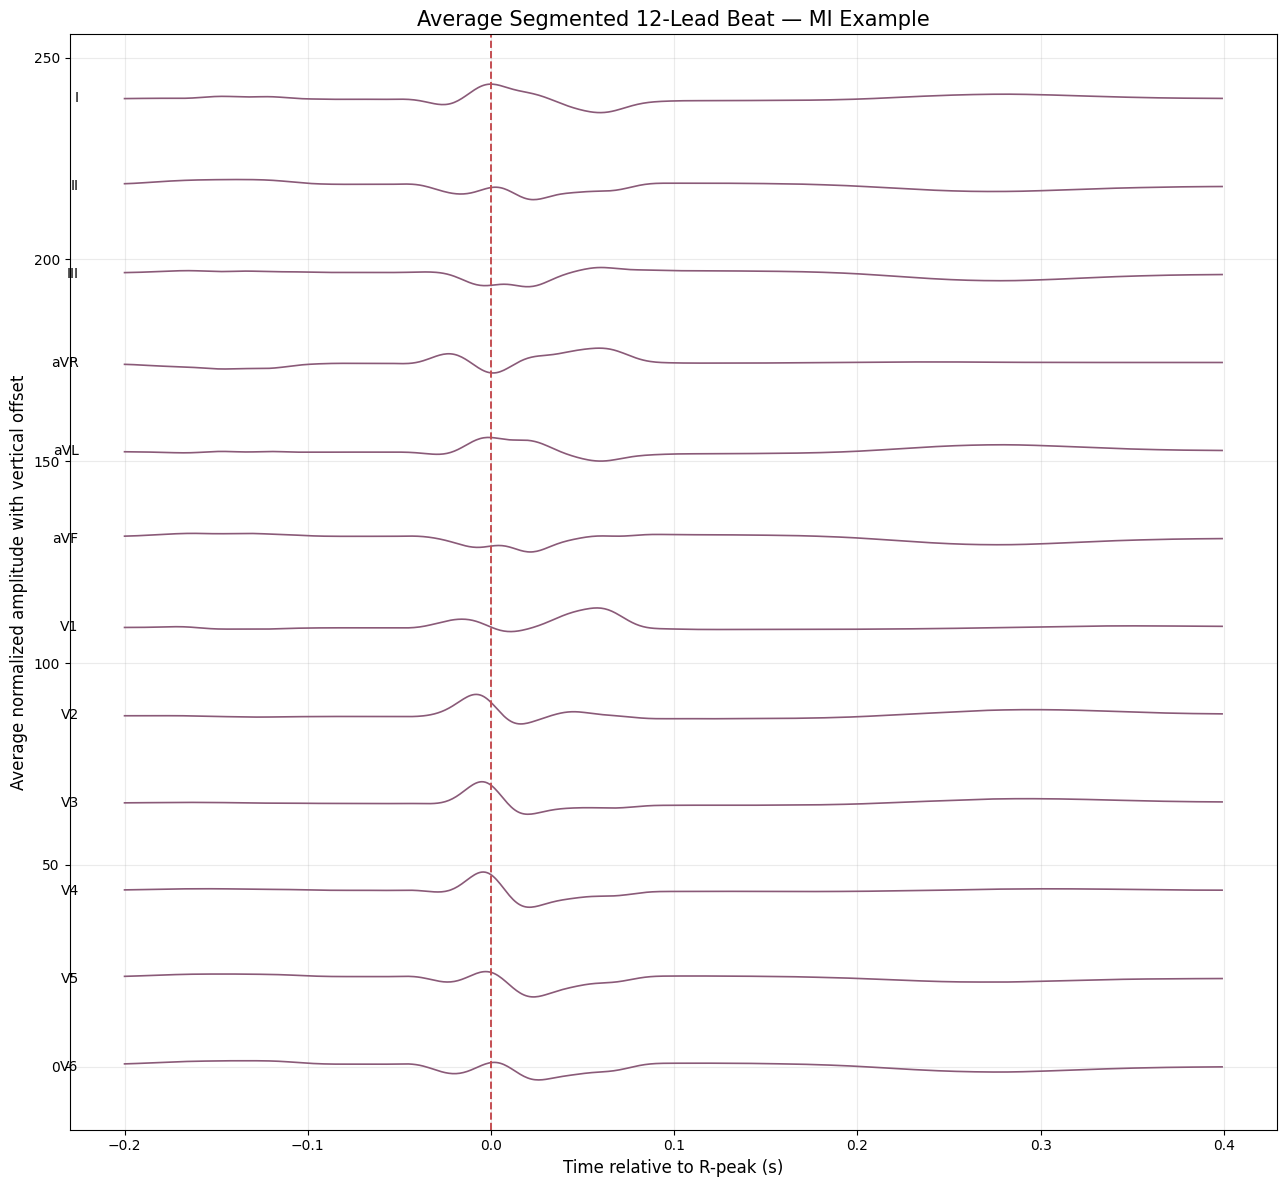

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook3_average_12lead_beat_mi_example.png


In [65]:
fig_path = FIGURE_DIR / "notebook3_average_12lead_beat_mi_example.png"

plot_average_12lead_beat(
    beats,
    beat_time,
    selected_leads,
    title="Average Segmented 12-Lead Beat — MI Example",
    output_path=fig_path
)

print("Saved figure to:", fig_path)

In [66]:
def process_one_record_for_segmentation(row):
    """
    Load, preprocess, detect R-peaks with NeuroKit2, and segment beats for one record.
    This function is used for visual quality checking on multiple examples.
    """
    raw_signal, fs, lead_names, record_info = load_ecg_record(row["record_path"])
    raw_12lead, selected_leads = select_standard_12_leads(raw_signal, lead_names)

    filtered_12lead, normalized_12lead, preprocessing_info = preprocess_ecg_signal(
        raw_12lead,
        fs,
        PREPROCESSING_CONFIG
    )

    rpeak_lead = SEGMENTATION_CONFIG["rpeak_lead"]
    rpeak_lead_idx = selected_leads.index(rpeak_lead)

    lead_signal_for_detection = filtered_12lead[:, rpeak_lead_idx]

    best_detection, candidates = detect_r_peaks_neurokit_best_direction(
        lead_signal_for_detection,
        fs,
        method=SEGMENTATION_CONFIG["rpeak_detection_method"],
        correct_artifacts=SEGMENTATION_CONFIG["correct_artifacts"]
    )

    r_peaks = best_detection["r_peaks"]

    beats, valid_r_peaks, beat_time = segment_beats_around_rpeaks(
        normalized_12lead,
        r_peaks,
        fs,
        pre_r_sec=SEGMENTATION_CONFIG["pre_r_sec"],
        post_r_sec=SEGMENTATION_CONFIG["post_r_sec"]
    )

    rpeak_summary = summarize_r_peaks(
        r_peaks,
        fs,
        signal_length=len(lead_signal_for_detection)
    )

    result = {
        "patient_id": row["patient_id"],
        "record_id": row["record_id"],
        "record_path": row["record_path"],
        "mi_detected": row["mi_detected"],
        "reason_for_admission": row["reason_for_admission"],
        "fs": fs,
        "duration_sec": record_info["duration_sec"],
        "rpeak_detection_direction": best_detection["direction"],
        "n_detected_rpeaks": len(r_peaks),
        "n_valid_beats": beats.shape[0],
        "estimated_hr_from_count": rpeak_summary["estimated_hr_from_count"],
        "estimated_hr_from_median_rr": rpeak_summary["estimated_hr_from_median_rr"],
        "rr_mean_sec": rpeak_summary["rr_mean_sec"],
        "rr_median_sec": rpeak_summary["rr_median_sec"],
        "rr_std_sec": rpeak_summary["rr_std_sec"]
    }

    data = {
        "filtered_12lead": filtered_12lead,
        "normalized_12lead": normalized_12lead,
        "selected_leads": selected_leads,
        "r_peaks": r_peaks,
        "valid_r_peaks": valid_r_peaks,
        "beats": beats,
        "beat_time": beat_time,
        "fs": fs,
        "rpeak_detection_direction": best_detection["direction"]
    }

    return result, data


print("Still using old function name?")
print("detect_r_peaks_from_lead" in process_one_record_for_segmentation.__code__.co_names)

Still using old function name?
False


In [67]:
example_records = pd.concat([
    detection_df[detection_df["mi_detected"] == 1].head(3),
    detection_df[detection_df["mi_detected"] == 0].head(3)
]).reset_index(drop=True)

display(example_records[["patient_id", "record_id", "reason_for_admission", "mi_detected", "record_path"]])

,patient_id,record_id,reason_for_admission,mi_detected,record_path
0,patient001,s0010_re,Myocardial infarction,1,ptb-diagnostic-ecg-database-1.0.0\patient001\s...
1,patient001,s0014lre,Myocardial infarction,1,ptb-diagnostic-ecg-database-1.0.0\patient001\s...
2,patient001,s0016lre,Myocardial infarction,1,ptb-diagnostic-ecg-database-1.0.0\patient001\s...
3,patient104,s0306lre,Healthy control,0,ptb-diagnostic-ecg-database-1.0.0\patient104\s...
4,patient105,s0303lre,Healthy control,0,ptb-diagnostic-ecg-database-1.0.0\patient105\s...
5,patient116,s0302lre,Healthy control,0,ptb-diagnostic-ecg-database-1.0.0\patient116\s...


In [68]:
example_results = []
example_data = {}

for idx, row in example_records.iterrows():
    print("=" * 80)
    print("Processing:", row["patient_id"], row["record_id"], row["reason_for_admission"])

    try:
        result, data = process_one_record_for_segmentation(row)
        example_results.append(result)

        key = f"{row['patient_id']}_{row['record_id']}"
        example_data[key] = data

        print("Direction:", result["rpeak_detection_direction"])
        print("Detected R-peaks:", result["n_detected_rpeaks"])
        print("Valid beats:", result["n_valid_beats"])
        print("Estimated HR:", result["estimated_hr_from_median_rr"])

    except Exception as e:
        print("Failed:", e)

        result = {
            "patient_id": row["patient_id"],
            "record_id": row["record_id"],
            "record_path": row["record_path"],
            "mi_detected": row["mi_detected"],
            "reason_for_admission": row["reason_for_admission"],
            "error": str(e)
        }

        example_results.append(result)

example_results_df = pd.DataFrame(example_results)

display(example_results_df)

Processing: patient001 s0010_re Myocardial infarction
Direction: original
Detected R-peaks: 52
Valid beats: 51
Estimated HR: 81.74386920980926
Processing: patient001 s0014lre Myocardial infarction
Direction: inverted
Detected R-peaks: 165
Valid beats: 165
Estimated HR: 86.33093525179856
Processing: patient001 s0016lre Myocardial infarction
Direction: inverted
Detected R-peaks: 153
Valid beats: 153
Estimated HR: 79.7872340425532
Processing: patient104 s0306lre Healthy control
Direction: inverted
Detected R-peaks: 118
Valid beats: 118
Estimated HR: 61.601642710472284
Processing: patient105 s0303lre Healthy control
Direction: original
Detected R-peaks: 149
Valid beats: 148
Estimated HR: 78.48266841072596
Processing: patient116 s0302lre Healthy control
Direction: original
Detected R-peaks: 118
Valid beats: 117
Estimated HR: 62.11180124223603


,patient_id,record_id,record_path,mi_detected,reason_for_admission,fs,duration_sec,rpeak_detection_direction,n_detected_rpeaks,n_valid_beats,estimated_hr_from_count,estimated_hr_from_median_rr,rr_mean_sec,rr_median_sec,rr_std_sec
0,patient001,s0010_re,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,1,Myocardial infarction,1000,38.4,original,52,51,81.250000,81.743869,0.733765,0.7340,0.009226
1,patient001,s0014lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,1,Myocardial infarction,1000,115.2,inverted,165,165,85.937500,86.330935,0.695671,0.6950,0.005228
2,patient001,s0016lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,1,Myocardial infarction,1000,115.2,inverted,153,153,79.687500,79.787234,0.751362,0.7520,0.009696
3,patient104,s0306lre,ptb-diagnostic-ecg-database-1.0.0\patient104\s...,0,Healthy control,1000,115.2,inverted,118,118,61.458333,61.601643,0.969897,0.9740,0.063979
4,patient105,s0303lre,ptb-diagnostic-ecg-database-1.0.0\patient105\s...,0,Healthy control,1000,115.2,original,149,148,77.604167,78.482668,0.771473,0.7645,0.034776
5,patient116,s0302lre,ptb-diagnostic-ecg-database-1.0.0\patient116\s...,0,Healthy control,1000,115.2,original,118,117,61.458333,62.111801,0.972342,0.9660,0.025734


In [69]:
def plot_multiple_rpeak_examples(example_records, example_data, lead_name="ii", output_path=None):
    """
    Plot R-peak detection results for multiple MI and Healthy examples.
    """
    n = len(example_records)

    plt.figure(figsize=(14, 3.2 * n))

    for idx, row in example_records.iterrows():
        key = f"{row['patient_id']}_{row['record_id']}"

        if key not in example_data:
            continue

        data = example_data[key]

        normalized_12lead = data["normalized_12lead"]
        selected_leads = data["selected_leads"]
        r_peaks = data["r_peaks"]
        fs = data["fs"]

        lead_idx = selected_leads.index(lead_name.lower())

        start_sec = 0
        duration_sec = 5
        start_sample = int(start_sec * fs)
        end_sample = int((start_sec + duration_sec) * fs)

        signal_seg = normalized_12lead[start_sample:end_sample, lead_idx]
        t = np.arange(len(signal_seg)) / fs + start_sec

        peaks_in_window = r_peaks[
            (r_peaks >= start_sample) & (r_peaks < end_sample)
        ]

        label = "MI" if row["mi_detected"] == 1 else "Healthy Control"

        plt.subplot(n, 1, idx + 1)

        plt.plot(
            t,
            signal_seg,
            color=PURPLE_DARK,
            linewidth=1.0,
            label="Normalized ECG"
        )

        plt.scatter(
            peaks_in_window / fs,
            normalized_12lead[peaks_in_window, lead_idx],
            color=RED_SOFT,
            s=28,
            zorder=3,
            label="Detected R-peaks"
        )

        plt.title(
            f"{label} — {row['patient_id']} / {row['record_id']} — Lead {LEAD_DISPLAY_NAMES[lead_name]}"
        )
        plt.xlabel("Time (s)")
        plt.ylabel("Normalized amplitude")
        plt.grid(alpha=0.25)

        if idx == 0:
            plt.legend(loc="upper right")

    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300)

    plt.show()

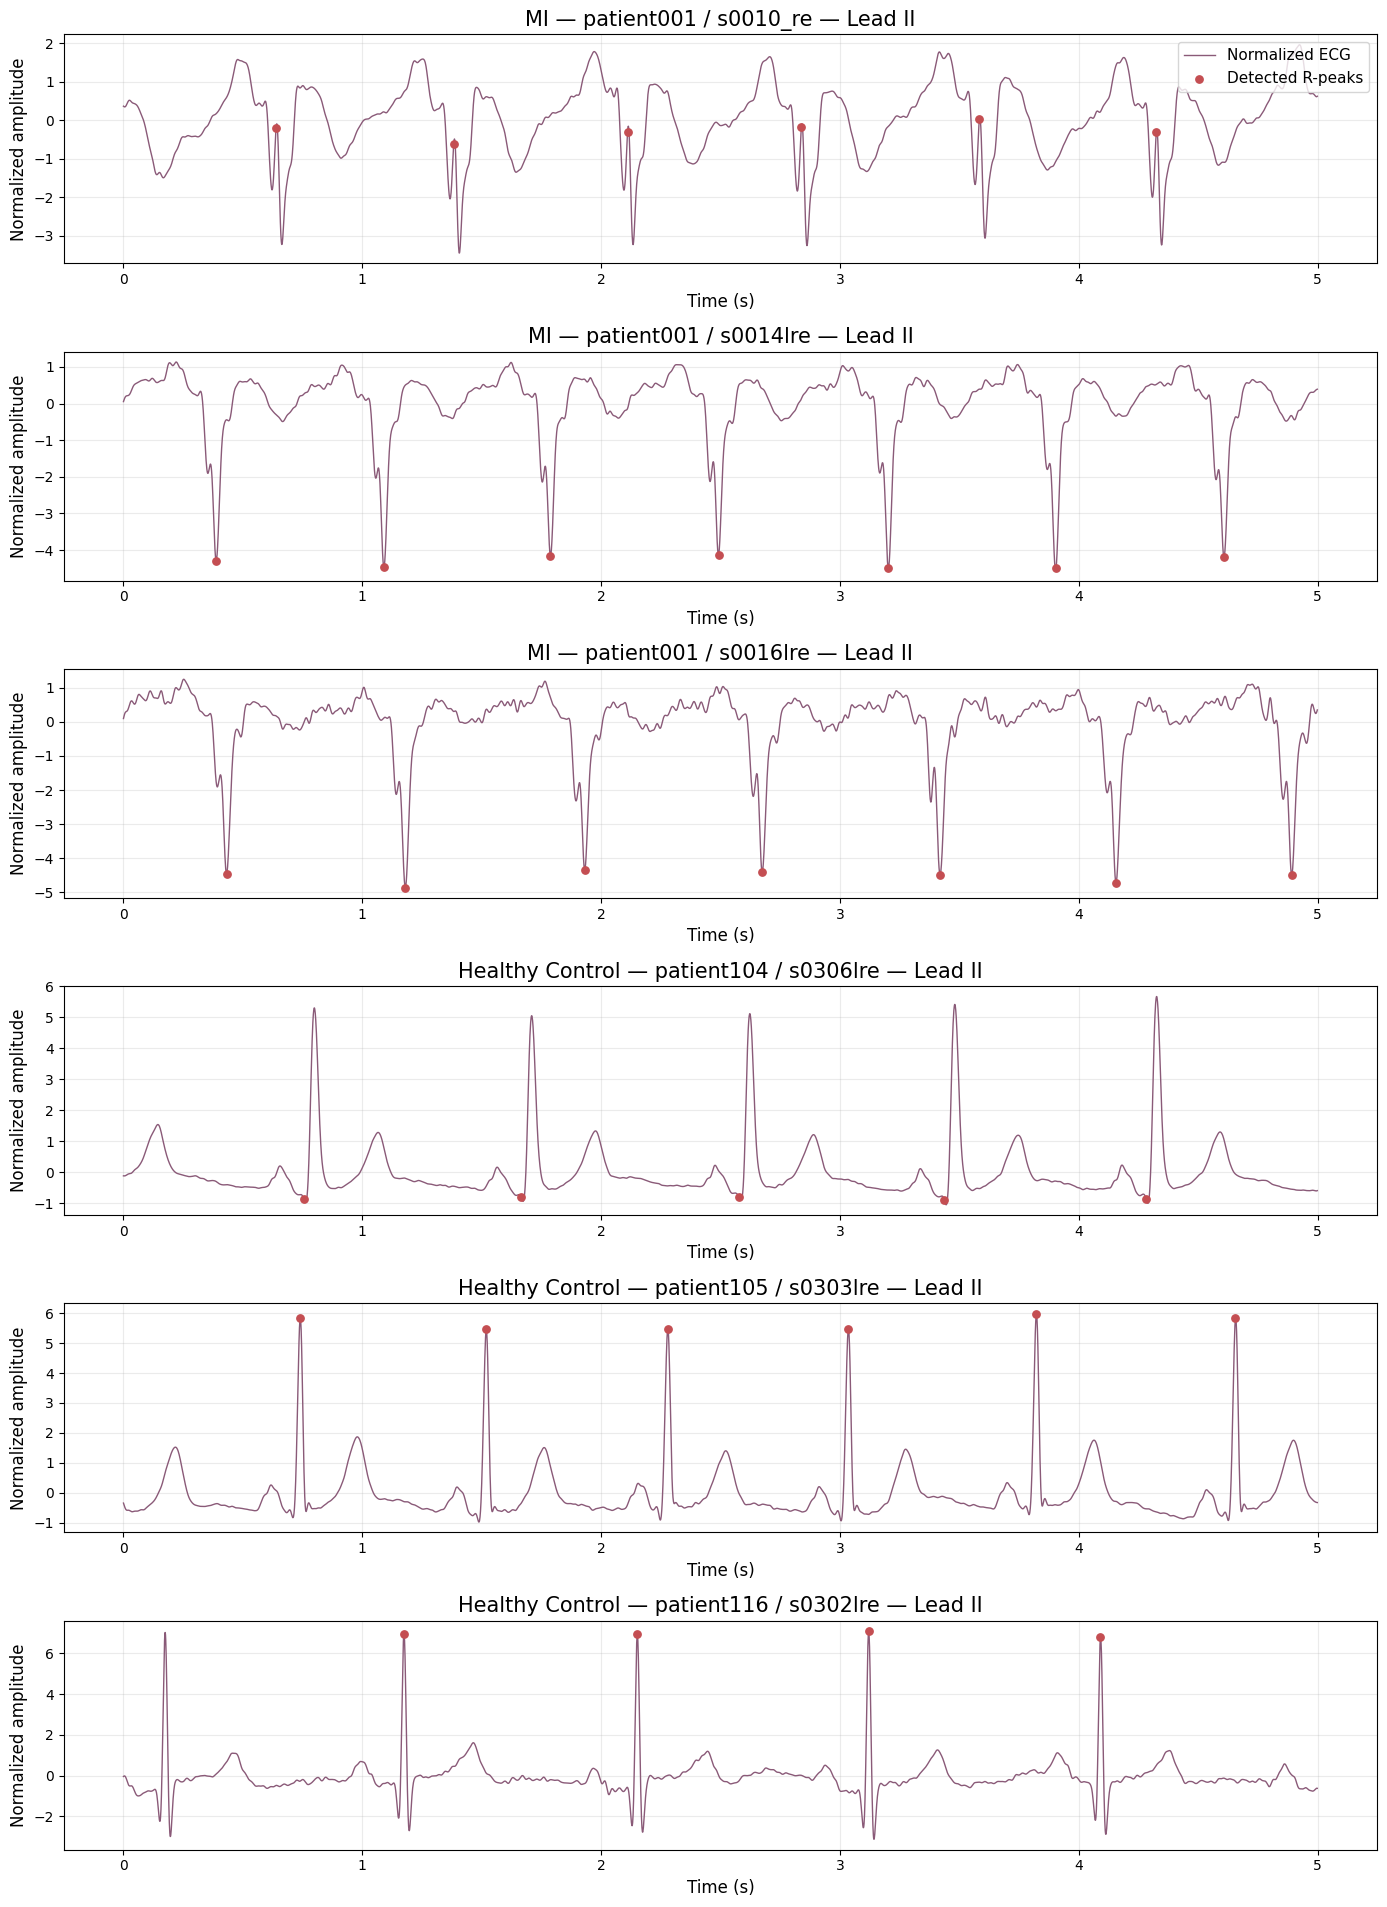

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook3_multiple_rpeak_detection_examples.png


In [70]:
fig_path = FIGURE_DIR / "notebook3_multiple_rpeak_detection_examples.png"

plot_multiple_rpeak_examples(
    example_records,
    example_data,
    lead_name="ii",
    output_path=fig_path
)

print("Saved figure to:", fig_path)

In [71]:
summary_output_path = TABLE_DIR / "notebook3_example_segmentation_summary.csv"

example_results_df.to_csv(summary_output_path, index=False, encoding="utf-8-sig")

print("Saved segmentation summary to:")
print(summary_output_path)

Saved segmentation summary to:
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook3_example_segmentation_summary.csv


In [72]:
segmentation_config_path = TABLE_DIR / "notebook3_segmentation_config.json"

with open(segmentation_config_path, "w", encoding="utf-8") as f:
    json.dump(SEGMENTATION_CONFIG, f, indent=4)

print("Saved segmentation configuration to:")
print(segmentation_config_path)

Saved segmentation configuration to:
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook3_segmentation_config.json
